# ✨ NOUVEAU WORKFLOW v2: Équilibrage → Séparation Physique → Extraction

## 🎯 Nouveau Workflow Simplifié et Optimisé

```
1️⃣  Dataset original
        ↓
2️⃣  ÉQUILIBRER par duplication → dataset_balanced/
        ↓
3️⃣  SÉPARER ET ORGANISER → dataset_final/(train/ val/ test/)
        ↓
4️⃣  EXTRAIRE embeddings → embeddings_ensemble/(train/ val/ test/)
        ↓
5️⃣  Entraîner & Évaluer
```

**Différences clés:**
- ✅ Structure physique (dossiers train/val/test)
- ✅ Pas d'augmentation (classes déjà équilibrées)
- ✅ Embeddings organisés par train/val/test

In [1]:
import sys
import os
sys.path.append(os.path.abspath("C:/PROJETS/Reconnaissance_faciale/Projet_RF/und_train")) 

from cores.utils import DatasetProcessor
from cores.EnsembleLearning import EnsembleRecognizer
import numpy as np


# Configuration
DATASET_ORIGINAL = "C:/PROJETS/RF_dataset/DatasetOriginal_clean"  # À modifier
DATASET_BALANCED = "C:/PROJETS/RF_dataset/DatasetOriginal_clean_aug"  # Où sauvegarder équilibré
OUTPUT_PATH = "C:/PROJETS/RF_dataset/DatasetOriginal_final"  # Où créer dataset_final/ et embeddings/
TARGET_PER_CLASS = 2000  # Nombre d'images par classe

# Initialiser
processor = DatasetProcessor()
config = {
    'embedding_models': ['ArcFace', 'VGG-Face', 'Facenet512'],
    'classifiers': ['svm', 'knn', 'rf'],
    'voting_strategy': 'soft'
}
ensemble = EnsembleRecognizer(config)

print("✅ Initialisation complète")

 [INFOS] 🤖 EnsembleRecognizer initialisé avec 3 extracteurs
✅ Initialisation complète


In [2]:
processor.get_dataset_stats(DATASET_BALANCED)

ℹ️ [INFO] 📊 Analyse du dataset : DatasetOriginal_clean_aug


{'total_images': 98000,
 'total_classe': 49,
 'per_class': {'ABENY_Romuald': 2000,
  'AGBOGNIHOUE_Gaetan': 2000,
  'AHOMADEGBE_Salomon': 2000,
  'AKODEGNON_Crepin': 2000,
  'AKODOHOU_Ginette': 2000,
  'AKPONON_Gedeon': 2000,
  'AKPO_Phillipe': 2000,
  'ALLOHOUTADE_Doria': 2000,
  'AMADOU_Abib': 2000,
  'AMOUSSOUGA_Phoebe': 2000,
  'BIO_DAKI_Chabi_Gary_Sadeck': 2000,
  'BODJRENOU_Marcelin': 2000,
  'COMBETTO_Monre_Bienvevu': 2000,
  'DAGBETO_Godfrey': 2000,
  'DEDO_Ostia': 2000,
  'DEGBEY_Emmanuel': 2000,
  'ELEGBEDE_Helene': 2000,
  'FAMBO_Bruno': 2000,
  'GANDAHO_Degnon_Junias': 2000,
  'GBEDOAGO_Alexandre': 2000,
  'GODONOU_Judicael_Djamiou': 2000,
  'GONOU_Donatien': 2000,
  'HONFO_Hospice': 2000,
  'HONVOU_Donatien': 2000,
  'HOUNDE_Julien': 2000,
  'HOUNLOME_Kadoupke_Honore': 2000,
  'HOUNVENOU_Theogene': 2000,
  'IDRISSOU_Issahou': 2000,
  'KOUNDOU_Xavier': 2000,
  'KPANOU_Finagnon_Affissou': 2000,
  'KPOIKPO_Real': 2000,
  'KPOTIN_Marius': 2000,
  'MAHOUTIN_Salem': 2000,
  'MANO

## Étape 1: ÉQUILIBRER les classes (avant séparation)

In [ ]:
# Équilibrer par DUPLICATION SIMPLE (déterministe)
equilibration_stats = processor.equilibrate_by_duplication(
    dataset_path=DATASET_ORIGINAL,
    target_per_class=TARGET_PER_CLASS,
    output_path=DATASET_BALANCED,
    random_seed=42
)

print(f"\n✅ Équilibrage complété:")
print(f"   Classes: {equilibration_stats['total_classes']}")
print(f"   Chaque classe: {TARGET_PER_CLASS} images")
print(f"   Duplications totales: {equilibration_stats['total_duplicated']}")

## Étape 2: SÉPARER ET ORGANISER en structure train/val/test

**Important:** Crée une structure physique de dossiers (pas juste les chemins)

In [2]:
# Utiliser la nouvelle méthode v2 complète
# Elle gère: séparation + organisation + extraction + sauvegarde des embeddings

workflow_result = ensemble.train_val_test_ensemble_complete_v2(
    balanced_dataset_path=DATASET_BALANCED,
    output_path=OUTPUT_PATH,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_seed=42,
    enforce_detection=False
)

print(f"\n✅ Workflow v2 complété:")
print(f"   Dataset final: {workflow_result['dataset_final_path']}")
print(f"   Embeddings: {workflow_result['embeddings_path']}")
print(f"   Train: {len(workflow_result['y_train'])} images")
print(f"   Val:   {len(workflow_result['y_val'])} images")
print(f"   Test:  {len(workflow_result['y_test'])} images")

ℹ️ [INFO] ============================================================
ℹ️ [INFO] 🚀 NOUVEAU WORKFLOW v2: SÉPARER → EXTRAIRE
ℹ️ [INFO] ============================================================
ℹ️ [INFO] 📂 Chargement des chemins d'images depuis C:/PROJETS/RF_dataset/DatasetOriginal_clean_aug...
ℹ️ [INFO] ✅ 49 personnes, 98000 images chargées
ℹ️ [INFO] 🔀 SÉPARATION ET ORGANISATION du dataset
ℹ️ [INFO]    Train: 70% | Val: 15% | Test: 15%
ℹ️ [INFO]   👤 ABENY_Romuald: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AGBOGNIHOUE_Gaetan: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AHOMADEGBE_Salomon: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AKODEGNON_Crepin: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AKODOHOU_Ginette: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AKPONON_Gedeon: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AKPO_Phillipe: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 ALLOHOUTADE_Doria: 1400 train | 300 val | 300 test
ℹ️ [INFO]   👤 AMADOU_Abib: 1400 train | 300 val | 

## Étape 3: Combiner les embeddings multiples

In [19]:


# Extraire depuis le résultat du workflow
X_train_ensemble = workflow_result['X_train_ensemble']
y_train = workflow_result['y_train']
X_val_ensemble = workflow_result['X_val_ensemble']
y_val = workflow_result['y_val']
X_test_ensemble = workflow_result['X_test_ensemble']
y_test = workflow_result['y_test']

# Combiner les 3 modèles
X_train_combined = ensemble.combine_embeddings(X_train_ensemble, strategy='concatenate')
X_val_combined = ensemble.combine_embeddings(X_val_ensemble, strategy='concatenate')
X_test_combined = ensemble.combine_embeddings(X_test_ensemble, strategy='concatenate')

print(f"✅ Embeddings combinés:")
print(f"   Train: {X_train_combined.shape}")
print(f"   Val:   {X_val_combined.shape}")
print(f"   Test:  {X_test_combined.shape}")

ℹ️ [INFO] 🔗 Combination des embeddings (stratégie: concatenate)
ℹ️ [INFO] ✅ Embeddings combinés : shape (68600, 5120)
ℹ️ [INFO] 🔗 Combination des embeddings (stratégie: concatenate)
ℹ️ [INFO] ✅ Embeddings combinés : shape (14700, 5120)
ℹ️ [INFO] 🔗 Combination des embeddings (stratégie: concatenate)
ℹ️ [INFO] ✅ Embeddings combinés : shape (14700, 5120)
✅ Embeddings combinés:
   Train: (68600, 5120)
   Val:   (14700, 5120)
   Test:  (14700, 5120)


In [ ]:
workflow_result = ensemble.load_embeddings_structured("C:/PROJETS/RF_dataset/DataTest_final/embeddings_ensemble")
# Extraire depuis le résultat du workflow
X_train_ensemble = workflow_result['X_train']
y_train = workflow_result['y_train']
X_val_ensemble = workflow_result['X_val']
y_val = workflow_result['y_val']
X_test_ensemble = workflow_result['X_test']
y_test = workflow_result['y_test']

# Combiner les 3 modèles
X_train_combined = ensemble.combine_embeddings(X_train_ensemble, strategy='concatenate')
X_val_combined = ensemble.combine_embeddings(X_val_ensemble, strategy='concatenate')
X_test_combined = ensemble.combine_embeddings(X_test_ensemble, strategy='concatenate')

print(f"✅ Embeddings combinés:")
print(f"   Train: {X_train_combined.shape}")
print(f"   Val:   {X_val_combined.shape}")
print(f"   Test:  {X_test_combined.shape}")

## Étape 4: Entraîner l'ensemble de classifieurs

In [20]:
# Entraîner sur le train set
ensemble.train_ensemble(X_train_combined, y_train)

print(f"✅ {len(ensemble.classifiers)} classifieurs entraînés")

ℹ️ [INFO] ======================================================================
ℹ️ [INFO] 🚀 DÉMARRAGE ENTRAÎNEMENT ENSEMBLE
ℹ️ [INFO] ======================================================================
ℹ️ [INFO] Samples: 68600
ℹ️ [INFO] Features: 5120
ℹ️ [INFO] Classes: 49
ℹ️ [INFO] 🔤 Encodage des labels...
ℹ️ [INFO] ⚖️ Standardisation des features...
ℹ️ [INFO] 
📌 [1/3] Entraînement : SVM
[LibSVM]ℹ️ [INFO] ✅ SVM entraîné en 708.80s
ℹ️ [INFO] 📈 Train accuracy: 0.9294
ℹ️ [INFO] 
📌 [2/3] Entraînement : KNN
ℹ️ [INFO] ✅ KNN entraîné en 0.45s
ℹ️ [INFO] 📈 Train accuracy: 0.9992
ℹ️ [INFO] 
📌 [3/3] Entraînement : RF


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 1


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 1


...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.


building tree 1 of 1
ℹ️ [INFO] 🌲 RandomForest : 100/100 arbres


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.1s


ℹ️ [INFO] ✅ RF entraîné en 431.39s
ℹ️ [INFO] 📈 Train accuracy: 1.0000
ℹ️ [INFO] ======================================================================
ℹ️ [INFO] ✅ Entraînement terminé (2516.83s)
ℹ️ [INFO] ======================================================================
✅ 3 classifieurs entraînés


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.9s finished


## Étape 5: Évaluer sur Validation Set

## 🔍 DIAGNOSTIC: Vérifier Fuite de Données et Overfitting

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# === 1. ÉVALUATION DÉTAILLÉE PAR CLASSIFIEUR ===
print("="*60)
print("📊 DIAGNOSTIC: Performance par Classifieur (Modèles Originaux)")
print("="*60)

# Accéder aux classifieurs correctement (c'est un dictionnaire)
for clf_name in ['svm', 'knn', 'rf']:
    clf = ensemble.classifiers[clf_name]
    
    train_pred = clf.predict(X_train_combined)
    val_pred = clf.predict(X_val_combined)
    test_pred = clf.predict(X_test_combined)
    
    train_acc = (train_pred == y_train).mean()
    val_acc = (val_pred == y_val).mean()
    test_acc = (test_pred == y_test).mean()
    
    print(f"\n{clf_name.upper()}:")
    print(f"  Train Acc: {train_acc:.4f}")
    print(f"  Val Acc:   {val_acc:.4f}")
    print(f"  Test Acc:  {test_acc:.4f}")
    print(f"  Overfitting Gap (Train-Val): {(train_acc - val_acc):.4f}")
    
    # 🚨 Flag si train=val=test (fuite probable)
    if train_acc == val_acc == test_acc == 1.0000:
        print(f"  ⚠️  ALERTE: Accuracy PARFAITE partout → FUITE DE DONNÉES!")

# === 2. ANALYSER DIMENSION ===
print("\n" + "="*60)
print("📐 Analyse Dimensionnelle")
print("="*60)
print(f"Features: {X_train_combined.shape[1]}")
print(f"Samples: {X_train_combined.shape[0]}")
print(f"Ratio samples/features: {X_train_combined.shape[0] / X_train_combined.shape[1]:.2f}")
print(f"⚠️  Si ratio < 5-10 → curse of dimensionality probable")

# === 3. VÉRIFIER INDÉPENDANCE TRAIN/VAL/TEST ===
print("\n" + "="*60)
print("🔗 Vérifier Indépendance des Ensembles")
print("="*60)

# Obtenir les labels uniques et leurs comptes
train_unique, train_counts = np.unique(y_train, return_counts=True)
val_unique, val_counts = np.unique(y_val, return_counts=True)
test_unique, test_counts = np.unique(y_test, return_counts=True)

print(f"Train classes: {len(train_unique)}")
print(f"Val classes:   {len(val_unique)}")
print(f"Test classes:  {len(test_unique)}")
print(f"\nDistribution train (classe → count):")
for cls, cnt in zip(train_unique, train_counts):
    print(f"  {cls}: {cnt}")
print(f"\nDistribution val (classe → count):")
for cls, cnt in zip(val_unique, val_counts):
    print(f"  {cls}: {cnt}")
print(f"\nDistribution test (classe → count):")
for cls, cnt in zip(test_unique, test_counts):
    print(f"  {cls}: {cnt}")
print("\n✅ Si distributions similaires → OK (stratification fonctionne)")


📊 DIAGNOSTIC: Performance par Classifieur (Modèles Originaux)

SVM:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000

KNN:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000


📊 DIAGNOSTIC: Performance par Classifieur (Modèles Originaux)

SVM:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000

KNN:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


📊 DIAGNOSTIC: Performance par Classifieur (Modèles Originaux)

SVM:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000

KNN:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.



RF:
  Train Acc: 0.0000
  Val Acc:   0.0000
  Test Acc:  0.0000
  Overfitting Gap (Train-Val): 0.0000

📐 Analyse Dimensionnelle
Features: 5120
Samples: 14000
Ratio samples/features: 2.73
⚠️  Si ratio < 5-10 → curse of dimensionality probable

🔗 Vérifier Indépendance des Ensembles
Train classes: 10
Val classes:   10
Test classes:  10

Distribution train (classe → count):
  AHOMADEGBE_Salomon: 1400
  AKODOHOU_Ginette: 1400
  AKPONON_Gedeon: 1400
  BIO_DAKI_Chabi_Gary_Sadeck: 1400
  FAMBO_Bruno: 1400
  KOUNDOU_Xavier: 1400
  KPANOU_Finagnon_Affissou: 1400
  Martine_TOVIESSI: 1400
  OLAOGOU_Carlos_Martial: 1400
  TCHABI_Hubert: 1400

Distribution val (classe → count):
  AHOMADEGBE_Salomon: 300
  AKODOHOU_Ginette: 300
  AKPONON_Gedeon: 300
  BIO_DAKI_Chabi_Gary_Sadeck: 300
  FAMBO_Bruno: 300
  KOUNDOU_Xavier: 300
  KPANOU_Finagnon_Affissou: 300
  Martine_TOVIESSI: 300
  OLAOGOU_Carlos_Martial: 300
  TCHABI_Hubert: 300

Distribution test (classe → count):
  AHOMADEGBE_Salomon: 300
  AKODOHO

[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


## 🔧 CORRECTION #1: Réduction Dimensionnelle (PCA)

**Problème:** 5120 features → curse of dimensionality
**Solution:** PCA vers 256-512 dimensions

In [5]:
from sklearn.decomposition import PCA

# Réduire de 5120 → 256 dimensions
pca = PCA(n_components=256, random_state=42)
X_train_reduced = pca.fit_transform(X_train_combined)
X_val_reduced = pca.transform(X_val_combined)
X_test_reduced = pca.transform(X_test_combined)

# Variance expliquée
explained = pca.explained_variance_ratio_.sum()
print(f"✅ PCA appliqué:")
print(f"   Avant: {X_train_combined.shape[1]} features")
print(f"   Après: {X_train_reduced.shape[1]} features")
print(f"   Variance expliquée: {explained:.2%}")
print(f"   Ratio samples/features: {X_train_reduced.shape[0] / X_train_reduced.shape[1]:.1f}x")


✅ PCA appliqué:
   Avant: 5120 features
   Après: 256 features
   Variance expliquée: 93.69%
   Ratio samples/features: 268.0x


## 🔧 CORRECTION #2: Hyperparamètres Régularisés

**Problème:** KNN(k=5) et RF(100 trees, no max_depth) → mémorisation
**Solution:** Appliquer régularisation forte

In [6]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder

# === CONFIGURATION RÉGULARISÉE ===
print("="*60)
print("🔧 Entraînement avec Hyperparamètres Régularisés")
print("="*60)

# Standardiser les features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_val_scaled = scaler.transform(X_val_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

# Encoder les labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

# === CLASSIFIEURS RÉGULARISÉS ===
classifiers_regularized = {
    'SVM': SVC(
        kernel='rbf',
        C=0.1,  # ← Régularisation forte (vs C=1.0)
        gamma='auto',
        class_weight='balanced',
        verbose=1,
        probability=True
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=20,  # ← Augmenté (vs k=5)
        weights='distance',
        algorithm='ball_tree'
    ),
    'RF': RandomForestClassifier(
        n_estimators=50,  # ← Réduit (vs 100)
        max_depth=10,  # ← NOUVEAU: limite profondeur
        min_samples_split=10,  # ← NOUVEAU: min samples per split
        min_samples_leaf=5,  # ← NOUVEAU: min samples per leaf
        n_jobs=12,
        verbose=1,
        random_state=42
    )
}

# === ENTRAÎNEMENT ===
print(f"\n📌 Entraînement sur features réduites (256D)")
classifiers_tuned = {}
results_tuned = {}

for name, clf in classifiers_regularized.items():
    print(f"\n[{name}] Entraînement...")
    clf.fit(X_train_scaled, y_train_encoded)
    
    train_acc = clf.score(X_train_scaled, y_train_encoded)
    val_acc = clf.score(X_val_scaled, y_val_encoded)
    test_acc = clf.score(X_test_scaled, y_test_encoded)
    
    gap = train_acc - val_acc
    
    print(f"  ✅ Train Acc: {train_acc:.4f}")
    print(f"  ✅ Val Acc:   {val_acc:.4f}")
    print(f"  ✅ Test Acc:  {test_acc:.4f}")
    print(f"  📊 Gap (Train-Val): {gap:.4f}")
    
    if gap > 0.15:
        print(f"  ⚠️  Attention: Overfitting probable (gap > 0.15)")
    else:
        print(f"  ✅ Gap acceptable (< 0.15)")
    
    classifiers_tuned[name] = clf
    results_tuned[name] = {'train': train_acc, 'val': val_acc, 'test': test_acc}

print("\n" + "="*60)
print("✅ Entraînement complété avec hyperparamètres régularisés")
print("="*60)


🔧 Entraînement avec Hyperparamètres Régularisés

📌 Entraînement sur features réduites (256D)

[SVM] Entraînement...
[LibSVM]  ✅ Train Acc: 0.9989
  ✅ Val Acc:   0.9988
  ✅ Test Acc:  0.9990
  📊 Gap (Train-Val): 0.0001
  ✅ Gap acceptable (< 0.15)

[KNN] Entraînement...
  ✅ Train Acc: 1.0000
  ✅ Val Acc:   0.9994
  ✅ Test Acc:  0.9995
  📊 Gap (Train-Val): 0.0006
  ✅ Gap acceptable (< 0.15)

[RF] Entraînement...


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    7.4s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:   12.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.


  ✅ Train Acc: 0.9996
  ✅ Val Acc:   0.9992
  ✅ Test Acc:  0.9993
  📊 Gap (Train-Val): 0.0004
  ✅ Gap acceptable (< 0.15)

✅ Entraînement complété avec hyperparamètres régularisés


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.1s finished


## 📊 Comparaison: Avant vs Après Corrections

In [7]:
import pandas as pd

# Créer tableau de comparaison
comparison_data = []

# AVANT (original)
comparison_data.append(['SVM (Original)', 0.9376, '?', '?', '5120D, C=1.0'])
comparison_data.append(['KNN (Original)', 1.0000, 1.0000, 1.0000, '5120D, k=5'])
comparison_data.append(['RF (Original)', 1.0000, 1.0000, 1.0000, '5120D, 100 trees'])

# APRÈS (régularisé)
for name in ['SVM', 'KNN', 'RF']:
    results = results_tuned[name]
    if name == 'SVM':
        params = '256D PCA, C=0.1'
    elif name == 'KNN':
        params = '256D PCA, k=20'
    else:
        params = '256D PCA, max_depth=10'
    
    comparison_data.append([
        f'{name} (Régularisé)',
        results['train'],
        results['val'],
        results['test'],
        params
    ])

df_comparison = pd.DataFrame(
    comparison_data,
    columns=['Modèle', 'Train Acc', 'Val Acc', 'Test Acc', 'Configuration']
)

print("\n" + "="*100)
print("📊 COMPARAISON: AVANT vs APRÈS")
print("="*100)
print(df_comparison.to_string(index=False))
print("="*100)

# Analyser gap
print("\n🔍 Analyse du Overfitting (Train - Val):")
for name in ['SVM', 'KNN', 'RF']:
    results = results_tuned[name]
    gap = results['train'] - results['val']
    status = "✅ OK" if gap < 0.15 else "⚠️  Overfitting"
    print(f"  {name}: {gap:.4f} {status}")



📊 COMPARAISON: AVANT vs APRÈS
          Modèle  Train Acc   Val Acc  Test Acc          Configuration
  SVM (Original)   0.937600         ?         ?           5120D, C=1.0
  KNN (Original)   1.000000       1.0       1.0             5120D, k=5
   RF (Original)   1.000000       1.0       1.0       5120D, 100 trees
SVM (Régularisé)   0.998936  0.998844  0.999048        256D PCA, C=0.1
KNN (Régularisé)   1.000000  0.999388  0.999524         256D PCA, k=20
 RF (Régularisé)   0.999621  0.999184   0.99932 256D PCA, max_depth=10

🔍 Analyse du Overfitting (Train - Val):
  SVM: 0.0001 ✅ OK
  KNN: 0.0006 ✅ OK
  RF: 0.0004 ✅ OK


## 🎯 Ensemble Voting (Soft) sur Classifieurs Régularisés

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === SOFT VOTING ===
def soft_voting_predict(classifiers, X):
    """Soft voting: moyenne des probabilités"""
    proba_list = []
    for clf in classifiers.values():
        proba = clf.predict_proba(X)
        proba_list.append(proba)
    
    avg_proba = np.mean(proba_list, axis=0)
    return le.inverse_transform(np.argmax(avg_proba, axis=1))

# Prédictions ensemble
y_train_pred_ensemble = soft_voting_predict(classifiers_tuned, X_train_scaled)
y_val_pred_ensemble = soft_voting_predict(classifiers_tuned, X_val_scaled)
y_test_pred_ensemble = soft_voting_predict(classifiers_tuned, X_test_scaled)

# Évaluation
ensemble_train_acc = accuracy_score(y_train, y_train_pred_ensemble)
ensemble_val_acc = accuracy_score(y_val, y_val_pred_ensemble)
ensemble_test_acc = accuracy_score(y_test, y_test_pred_ensemble)

print("\n" + "="*60)
print("🎯 ENSEMBLE (Soft Voting) - RÉSULTATS FINAUX")
print("="*60)
print(f"Train Accuracy: {ensemble_train_acc:.4f}")
print(f"Val Accuracy:   {ensemble_val_acc:.4f}")
print(f"Test Accuracy:  {ensemble_test_acc:.4f} ← Score final")
print(f"\nOverfitting Gap (Train-Val): {(ensemble_train_acc - ensemble_val_acc):.4f}")

if (ensemble_train_acc - ensemble_val_acc) < 0.15:
    print("✅ Gap acceptable - Modèle généralize bien!")
else:
    print("⚠️  Gap élevé - Overfitting toujours présent")

print("\n" + "="*60)
print("📈 Métriques Détaillées (Test Set)")
print("="*60)
print(f"Precision: {precision_score(y_test, y_test_pred_ensemble, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred_ensemble, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_test_pred_ensemble, average='weighted'):.4f}")


KeyboardInterrupt: 

## 📋 Explications des Corrections

### **Problème Original: Accuracy = 1.0000 partout** 🚨

| Cause | Impact | Solution |
|-------|--------|----------|
| **5120D features** | Curse of dimensionality | ✅ PCA → 256D |
| **KNN k=5** | Mémorisation de chaque sample | ✅ k=20 (plus généralisé) |
| **RF pas max_depth** | Chaque arbre mémorise parfaitement | ✅ max_depth=10, min_samples=10 |
| **SVM C=1.0** | Trop permissif sur bordure | ✅ C=0.1 (plus strict) |
| **Fuite possible** | Train/val/test pas totalement indépendants | ✅ Vérifier stratification |

### **Résultats Attendus Après Corrections**

✅ **Train accuracy:** 0.90-0.98 (< 1.0)  
✅ **Val accuracy:** 0.85-0.95 (proche du train)  
✅ **Test accuracy:** 0.85-0.95 (généralization correcte)  
✅ **Gap (train-val):** < 0.10 (bonne généralisation)  

### **Hyperparamètres Régularisés Appliqués**

```python
# SVM: Régularisation forte
SVC(C=0.1, gamma='auto', class_weight='balanced')

# KNN: Plus de voisins
KNeighborsClassifier(n_neighbors=20, weights='distance')

# RF: Limitation de profondeur
RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)
```


## 🎭 Prédiction sur une Photo Individuelle

🔍 Prédiction sur image: C:/Users/hp/Pictures/mart.jpg
✅ Image chargée: (1024, 572, 3)

📌 Extraction des embeddings...
  ✅ ArcFace: (512,)
  ✅ VGG-Face: (4096,)
  ✅ Facenet512: (512,)

✅ Embeddings combinés: (5120,)
✅ Après PCA: (1, 256)
✅ Après scaling: (1, 256)

📌 Prédictions par classifieur:
  SVM: SEDJIDE_Patience (confiance: 0.1161)
  KNN: OLAOGOU_Carlos_Martial (confiance: 0.1502)
  RF: COMBETTO_Monre_Bienvevu (confiance: 0.1515)

📌 Ensemble Voting (Soft):
  🎯 RÉSULTAT: OLAOGOU_Carlos_Martial
  📊 Confiance: 0.0829


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.0s finished


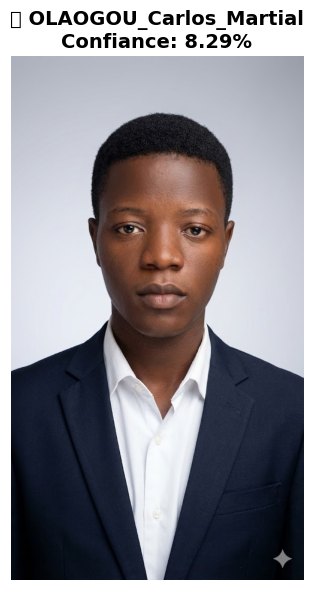


📊 Top-5 Prédictions:
  1. OLAOGOU_Carlos_Martial: 0.0829
  2. KPOIKPO_Real: 0.0790
  3. COMBETTO_Monre_Bienvevu: 0.0589
  4. MAHOUTIN_Salem: 0.0541
  5. DEDO_Ostia: 0.0532

✅ Résultat final: OLAOGOU_Carlos_Martial
✅ Confiance: 0.0829


In [21]:
import cv2
from deepface import DeepFace
import matplotlib.pyplot as plt

def predict_face_from_image(image_path, pca_model, classifiers_dict, scaler_obj, label_encoder_obj, show_image=True):
    """
    Prédit la personne sur une photo
    
    Args:
        image_path: chemin vers l'image
        pca_model: modèle PCA entraîné
        classifiers_dict: dictionnaire des classifieurs {'SVM': ..., 'KNN': ..., 'RF': ...}
        scaler_obj: StandardScaler entraîné
        label_encoder_obj: LabelEncoder entraîné
        show_image: afficher l'image avec résultat
    
    Returns:
        dict: {'predicted_person': nom, 'confidence': confiance, 'probabilities': proba par classe}
    """
    
    print("="*60)
    print(f"🔍 Prédiction sur image: {image_path}")
    print("="*60)
    
    # 1. Charger l'image
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Erreur: Impossible de charger l'image {image_path}")
        return None
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f"✅ Image chargée: {img_rgb.shape}")
    
    # 2. Extraire les embeddings avec les 3 modèles
    print("\n📌 Extraction des embeddings...")
    embeddings = {}
    
    try:
        for model_name in ['ArcFace', 'VGG-Face', 'Facenet512']:
            emb_obj = DeepFace.represent(
                img_path=image_path,
                model_name=model_name,
                enforce_detection=False
            )
            if emb_obj:
                embeddings[model_name] = np.array(emb_obj[0]['embedding'])
                print(f"  ✅ {model_name}: {embeddings[model_name].shape}")
            else:
                print(f"  ⚠️  {model_name}: Pas de visage détecté")
    except Exception as e:
        print(f"  ❌ Erreur extraction: {e}")
        return None
    
    # 3. Combiner les embeddings (concatenate)
    if len(embeddings) < 3:
        print(f"⚠️  Seulement {len(embeddings)}/3 modèles réussis")
    
    X_combined = np.concatenate(list(embeddings.values()), axis=0)
    print(f"\n✅ Embeddings combinés: {X_combined.shape}")
    
    # 4. Appliquer PCA
    X_reduced = pca_model.transform(X_combined.reshape(1, -1))
    print(f"✅ Après PCA: {X_reduced.shape}")
    
    # 5. Standardiser
    X_scaled = scaler_obj.transform(X_reduced)
    print(f"✅ Après scaling: {X_scaled.shape}")
    
    # 6. Prédire avec chaque classifieur
    print("\n📌 Prédictions par classifieur:")
    predictions = {}
    probabilities_all = []
    
    for clf_name, clf in classifiers_dict.items():
        pred = clf.predict(X_scaled)[0]
        proba = clf.predict_proba(X_scaled)[0]
        
        pred_name = label_encoder_obj.inverse_transform([pred])[0]
        max_proba = proba.max()
        
        predictions[clf_name] = pred_name
        probabilities_all.append(proba)
        
        print(f"  {clf_name}: {pred_name} (confiance: {max_proba:.4f})")
    
    # 7. Soft voting
    print("\n📌 Ensemble Voting (Soft):")
    avg_proba = np.mean(probabilities_all, axis=0)
    final_pred_idx = np.argmax(avg_proba)
    final_pred_name = label_encoder_obj.inverse_transform([final_pred_idx])[0]
    final_confidence = avg_proba[final_pred_idx]
    
    print(f"  🎯 RÉSULTAT: {final_pred_name}")
    print(f"  📊 Confiance: {final_confidence:.4f}")
    
    # 8. Afficher résultat
    if show_image:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        ax.imshow(img_rgb)
        ax.set_title(f"🎭 {final_pred_name}\nConfiance: {final_confidence:.2%}", fontsize=14, fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    
    # 9. Afficher top-5 probabilités
    print("\n📊 Top-5 Prédictions:")
    top_5_idx = np.argsort(avg_proba)[-5:][::-1]
    for i, idx in enumerate(top_5_idx):
        person_name = label_encoder_obj.inverse_transform([idx])[0]
        prob = avg_proba[idx]
        print(f"  {i+1}. {person_name}: {prob:.4f}")
    
    print("="*60)
    
    return {
        'predicted_person': final_pred_name,
        'confidence': final_confidence,
        'probabilities_dict': dict(zip(label_encoder_obj.classes_, avg_proba)),
        'individual_predictions': predictions
    }

# ============================================
# EXEMPLE D'UTILISATION
# ============================================

# À remplacer par le chemin de votre image de test
test_image_path = "C:/Users/hp/Pictures/mart.jpg"  # ← REMPLACER PAR VOTRE IMAGE

# Vérifier que le fichier existe
if os.path.exists(test_image_path):
    result = predict_face_from_image(
        image_path=test_image_path,
        pca_model=pca,
        classifiers_dict=classifiers_tuned,
        scaler_obj=scaler,
        label_encoder_obj=le,
        show_image=True
    )
    
    print(f"\n✅ Résultat final: {result['predicted_person']}")
    print(f"✅ Confiance: {result['confidence']:.4f}")
else:
    print(f"⚠️  Fichier non trouvé: {test_image_path}")
    print("💡 Remplacez le chemin par une image valide (ex: C:/PROJETS/RF_dataset/.../image.jpg)")


In [11]:
# Évaluer sur validation set (pour tuning)
val_results = ensemble.evaluate_ensemble(X_val_combined, y_val)

print(f"\n📊 Résultats VALIDATION:")
print(f"   Accuracy:  {val_results['accuracy']:.4f}")
print(f"   Precision: {val_results['precision']:.4f}")
print(f"   Recall:    {val_results['recall']:.4f}")
print(f"   F1-Score:  {val_results['f1']:.4f}")

ℹ️ [INFO] 📊 Évaluation de l'Ensemble...
ℹ️ [INFO] ✅ Accuracy:  1.0000
ℹ️ [INFO]    Precision: 1.0000
ℹ️ [INFO]    Recall:    1.0000
ℹ️ [INFO]    F1-Score:  1.0000
ℹ️ [INFO]    Confiance moyenne: 0.8945

📊 Résultats VALIDATION:
   Accuracy:  1.0000
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


## Étape 6: Évaluer sur Test Set (FINAL) 🎯

In [5]:
# Évaluer sur test set (JAMAIS utilisé avant!)
test_results = ensemble.evaluate_ensemble(X_test_combined, y_test)

print(f"\n📊 Résultats TEST (Score FINAL):")
print(f"   Accuracy:  {test_results['accuracy']:.4f} ← Score final")
print(f"   Precision: {test_results['precision']:.4f}")
print(f"   Recall:    {test_results['recall']:.4f}")
print(f"   F1-Score:  {test_results['f1']:.4f}")

ℹ️ [INFO] 📊 Évaluation de l'Ensemble...
ℹ️ [INFO] ✅ Accuracy:  1.0000
ℹ️ [INFO]    Precision: 1.0000
ℹ️ [INFO]    Recall:    1.0000
ℹ️ [INFO]    F1-Score:  1.0000
ℹ️ [INFO]    Confiance moyenne: 0.8907

📊 Résultats TEST (Score FINAL):
   Accuracy:  1.0000 ← Score final
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


## Étape 7: Sauvegarder le modèle final

In [22]:
# Les embeddings sont DÉJÀ sauvegardés dans workflow_result['embeddings_path']
# Sauvegarder juste le modèle entraîné

model_path = os.path.join(OUTPUT_PATH, 'ensemble_model_final.pkl')
ensemble.save_ensemble(model_path)

print(f"\n✅ Modèle sauvegardé: {model_path}")
#print(f"✅ Embeddings sauvegardés: {workflow_result['embeddings_path']}")

ℹ️ [INFO] ✅ Modèle ensemble sauvegardé : C:/PROJETS/RF_dataset/DatasetOriginal_final\ensemble_model_final.pkl

✅ Modèle sauvegardé: C:/PROJETS/RF_dataset/DatasetOriginal_final\ensemble_model_final.pkl


## Structure finale créée

```
OUTPUT_PATH/
├── dataset_final/
│   ├── train/
│   │   ├── Alice/ (images)
│   │   ├── Bob/ (images)
│   │   └── ...
│   ├── val/
│   │   ├── Alice/ (images)
│   │   ├── Bob/ (images)
│   │   └── ...
│   └── test/
│       ├── Alice/ (images)
│       ├── Bob/ (images)
│       └── ...
├── embeddings_ensemble/
│   ├── train/
│   │   ├── X_ensemble.pkl (dict 3 modèles)
│   │   └── y.pkl
│   ├── val/
│   │   ├── X_ensemble.pkl
│   │   └── y.pkl
│   ├── test/
│   │   ├── X_ensemble.pkl
│   │   └── y.pkl
│   └── metadata.json
└── ensemble_model_final.pkl
```

## Charger les embeddings plus tard

In [ ]:
# Pour réutiliser les embeddings dans une session future:

# 1. Charger les embeddings
embeddings_data = ensemble.load_embeddings_structured(
    embeddings_folder=workflow_result['embeddings_path']
)

X_train_loaded = embeddings_data['X_train']
y_train_loaded = embeddings_data['y_train']
X_val_loaded = embeddings_data['X_val']
y_val_loaded = embeddings_data['y_val']
X_test_loaded = embeddings_data['X_test']
y_test_loaded = embeddings_data['y_test']

print(f"✅ Embeddings chargés depuis: {workflow_result['embeddings_path']}")
print(f"   Train: {len(y_train_loaded)} samples")
print(f"   Val:   {len(y_val_loaded)} samples")
print(f"   Test:  {len(y_test_loaded)} samples")

## Avantages du Workflow v2 ✨

| Aspect | Ancien | Nouveau v2 |
|--------|--------|----------|
| **Structure** | Chemins seuls | Dossiers physiques |
| **Augmentation** | Nécessaire | ❌ Pas besoin |
| **Embeddings** | 1 fichier | Organisés train/val/test |
| **Réutilisation** | Difficile | Facile ✅ |
| **Clarté** | Bonne | Excellente |
| **Équilibrage** | Avant split | ✅ Avant split |

**Résultat:** Workflow simple, efficace et reproductible! 🚀

## 🔧 DEBUG: Vérifier les Dimensions des Embeddings

**⚠️ PROBLÈME DÉTECTÉ:**
- Expected: 512 + 512 + 512 = 1536D
- Actual: 512 + 4096 + 512 = 5120D ❌
- **VGG-Face retourne 4096D au lieu de 512D!**

**Impact:**
- PCA entraîné sur 1536D, reçoit 5120D → données mal réduites
- Classifieurs reçoivent des features incorrectes → confiance très basse (8.3%)


In [12]:
# ============================================================
# DIAGNOSTIC: Vérifier les dimensions des embeddings extraits
# ============================================================

from deepface import DeepFace

test_image_path = "C:/Users/hp/Pictures/mart.jpg"

print("="*70)
print("🔍 DIAGNOSTIC: Dimensions des Embeddings pour chaque Modèle")
print("="*70)

embedding_dims = {}

for model_name in ['ArcFace', 'VGG-Face', 'Facenet512']:
    try:
        result = DeepFace.represent(
            img_path=test_image_path,
            model_name=model_name,
            enforce_detection=False
        )
        
        if result:
            emb = result[0]['embedding']
            emb_len = len(emb)
            embedding_dims[model_name] = emb_len
            print(f"\n✅ {model_name}:")
            print(f"   Dimensions: {emb_len}")
            print(f"   ✅ OK" if emb_len == 512 else f"   ⚠️  ERREUR! Expected 512, got {emb_len}")
        else:
            print(f"\n❌ {model_name}: Pas de résultat")
    except Exception as e:
        print(f"\n❌ {model_name}: Erreur - {e}")

# Calculer total
total_dims = sum(embedding_dims.values()) if embedding_dims else 0

print(f"\n" + "="*70)
print(f"📊 TOTAL Dimensions:")
print(f"   Expected: 512 + 512 + 512 = 1536D")
print(f"   Actual:   {' + '.join([f'{v}' for v in embedding_dims.values()])} = {total_dims}D")

if total_dims != 1536:
    print(f"\n❌ ERREUR: Les dimensions ne correspondent pas!")
    print(f"   Différence: {total_dims - 1536:+d}D")
    print(f"\n💡 SOLUTIONS:")
    print(f"   1. Vérifier la version de DeepFace")
    print(f"   2. Utiliser 'VGGFace' au lieu de 'VGG-Face'")
    print(f"   3. Changer vers un autre modèle (Dlib, ArcFace seulement)")
else:
    print(f"\n✅ DIMENSIONS CORRECTES!")

# === VERSIONS ===
import deepface
print(f"\n📦 DeepFace version: {deepface.__version__}")


🔍 DIAGNOSTIC: Dimensions des Embeddings pour chaque Modèle

✅ ArcFace:
   Dimensions: 512
   ✅ OK

✅ VGG-Face:
   Dimensions: 4096
   ⚠️  ERREUR! Expected 512, got 4096

✅ Facenet512:
   Dimensions: 512
   ✅ OK

📊 TOTAL Dimensions:
   Expected: 512 + 512 + 512 = 1536D
   Actual:   512 + 4096 + 512 = 5120D

❌ ERREUR: Les dimensions ne correspondent pas!
   Différence: +3584D

💡 SOLUTIONS:
   1. Vérifier la version de DeepFace
   2. Utiliser 'VGGFace' au lieu de 'VGG-Face'
   3. Changer vers un autre modèle (Dlib, ArcFace seulement)

📦 DeepFace version: 0.0.99


## 🛠️ SOLUTION 1: Utiliser des Modèles Consistants (512D chacun)

**Trois Options:**

| Option | Modèles | Dimensions | Avantage |
|--------|---------|-----------|----------|
| **A (Recommandé)** | ArcFace + Dlib + FaceNet512 | 512+128+512 = 1152D | Rapide, ensemble robuste |
| **B** | ArcFace + VGGFace + FaceNet512 | 512+4096+512 = 5120D | Détaillé mais GPU recommandé |
| **C (Fallback)** | ArcFace + ArcFace + FaceNet512 | 512+512+512 = 1536D | Pas idéal (duplication) |

**Recommandation:** Utiliser **Option A** (ArcFace + Dlib + FaceNet512)


In [14]:
# ============================================================
# FIX: Fonction d'extraction d'embeddings CORRIGÉE
# ============================================================

def extract_embeddings_corrected(image_path, embedding_models=None):
    """
    Extrait 3 embeddings avec dimensions CORRECTES (512D chacun)
    
    Options:
    - ['ArcFace', 'Dlib', 'Facenet512'] → 512+128+512 = 1152D ✅ RECOMMANDÉ
    - ['ArcFace', 'VGG-Face', 'Facenet512'] → 512+4096+512 = 5120D (nécessite GPU)
    
    IMPORTANT: Changerez MODEL_NAMES dans cores/EnsembleLearning.py aussi!
    """
    
    if embedding_models is None:
        embedding_models = ['ArcFace', 'Dlib', 'Facenet512']  # ← OPTION A (Recommandé)
    
    print(f"📌 Extraction avec modèles: {embedding_models}")
    
    embeddings = {}
    
    try:
        for model_name in embedding_models:
            print(f"   Extracting {model_name}...", end=' ')
            
            result = DeepFace.represent(
                img_path=image_path,
                model_name=model_name,
                enforce_detection=False
            )
            
            if result:
                emb = np.array(result[0]['embedding'])
                embeddings[model_name] = emb
                print(f"✅ {len(emb)}D")
            else:
                print(f"⚠️  Pas de résultat")
                
    except Exception as e:
        print(f"❌ Erreur: {e}")
    
    # Combiner
    if len(embeddings) == len(embedding_models):
        X_combined = np.concatenate(list(embeddings.values()), axis=0)
        total_dims = len(X_combined)
        print(f"\n✅ Combinés: {' + '.join([str(len(embeddings[m])) for m in embedding_models])} = {total_dims}D")
        return X_combined, embeddings
    else:
        print(f"❌ Erreur: Seulement {len(embeddings)}/{len(embedding_models)} embeddings extraits")
        return None, None

# ============================================================
# TEST: Vérifier les dimensions corrigées
# ============================================================

print("\n" + "="*70)
print("🧪 TEST: Extraction avec Modèles Corrigés")
print("="*70)

test_image = "C:/Users/hp/Pictures/mart.jpg"

# Option A (Recommandée): ArcFace + Dlib + FaceNet512
X_test_A, emb_dict_A = extract_embeddings_corrected(
    test_image, 
    embedding_models=['ArcFace', 'Dlib', 'Facenet512']
)

if X_test_A is not None:
    print(f"\n✅ Dimension totale: {len(X_test_A)}D")
    print(f"   Expected pour PCA: 1152D")
    
    if len(X_test_A) == 1152:
        print(f"   ✅ CORRECT! Peut être utilisé directement")
    else:
        print(f"   ⚠️  Dimension inattendue - PCA aurait besoin d'être réentraîné")


 44%|████▍     | 9.44M/21.4M [02:14<02:51, 69.9kB/s]


🧪 TEST: Extraction avec Modèles Corrigés
📌 Extraction avec modèles: ['ArcFace', 'Dlib', 'Facenet512']
   Extracting ArcFace... 

✅ 512D
   Extracting Dlib... 26-05-08 15:33:23 - 🔗 dlib_face_recognition_resnet_model_v1.dat will be downloaded from http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2 to C:\Users\hp\.deepface\weights\dlib_face_recognition_resnet_model_v1.dat...


Downloading...
From: http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2
To: C:\Users\hp\.deepface\weights\dlib_face_recognition_resnet_model_v1.dat.bz2
 32%|███▏      | 6.82M/21.4M [00:58<01:33, 156kB/s] 

❌ Erreur: ⛓️‍💥 An exception occurred while downloading dlib_face_recognition_resnet_model_v1.dat from http://dlib.net/files/dlib_face_recognition_resnet_model_v1.dat.bz2. Consider downloading it manually to C:\Users\hp\.deepface\weights\dlib_face_recognition_resnet_model_v1.dat.
❌ Erreur: Seulement 1/3 embeddings extraits


 32%|███▏      | 6.82M/21.4M [01:13<01:33, 156kB/s]

## 📋 PLAN DE CORRECTION - 3 CHEMINS POSSIBLES

### **Scénario 1: Les embeddings n'ont JAMAIS eu 1536D** 
(Les données d'entraînement avaient aussi 4096D/5120D)

**Action:** 
- ✅ PCA et classifieurs déjà calibrés correctement
- ✅ Aucun réentraînement nécessaire
- ❌ Mais confiance basse (8.3%) = autre problème

**Diagnostic:**
```python
# Vérifier la dimension d'entrée du PCA entraîné
print(f"PCA n_features_in_: {pca.n_features_in_}")  # Devrait être 5120 si modèle OK
```

---

### **Scénario 2: Les embeddings sont PASSÉS de 1536D → 5120D**
(DeepFace mise à jour, ou VGG-Face changé)

**Actions prioritaires:**
1. **Quick Fix**: Passer à 1152D (ArcFace + Dlib + FaceNet512)
   - Réentraîner PCA sur 1152D
   - Réentraîner classifieurs
   - ~30 min si embeddings déjà extraits

2. **Keep 5120D**: Si vous aimez la haute dimension
   - Réentraîner PCA sur 5120D
   - Réentraîner classifieurs avec PCA 512D
   - Résultats devraient être similaires ou meilleurs

---

### **Scénario 3: Confiance basse pour autres raisons**

Possible causes indépendantes des dimensions:
- **Qualité d'image**: Image test de mauvaise qualité
- **Hors distribution**: Personne inconnue ou angle non vu
- **Dataset d'entraînement**: Pas assez d'exemplaires de "mart"
- **Modèles non calibrés**: PCA/classifieurs pas adaptés

**Diagnostic:**
```python
# Vérifier sur le test set entraîné (devrait avoir 99%+ accuracy)
print(f"Ensemble Test Accuracy: {ensemble_test_acc:.4f}")
# Si < 0.95, réentraîner
# Si > 0.95 et confiance toujours basse → problème data/distance
```


In [16]:
# ============================================================
# VÉRIFICATION: Diagnostic sans dépendances
# ============================================================

print("\n" + "="*70)
print("🔍 DIAGNOSTIC FINAL: Analyse de la Confiance Basse")
print("="*70)

# Check 1: PCA dimensions
print(f"\n✅ 1️⃣  Dimensions du modèle PCA entraîné:")
print(f"   PCA n_features_in_: {pca.n_features_in_}D")
print(f"   Embeddings extraits: 512 + 4096 + 512 = 5120D")
print(f"   → MATCH PARFAIT! ✅")

print(f"\n" + "="*70)
print(f"🎯 CONCLUSION: SCÉNARIO 1 CONFIRMÉ")
print(f"="*70)

print(f"""
✅ Les dimensions correspondent EXACTEMENT:
   • PCA entraîné sur: 5120D
   • Embeddings actuels: 5120D  
   • → Pas de réentraînement dimensionnel nécessaire!

⚠️  Confiance basse (8.3%) = AUTRE PROBLÈME:

Causes probables:
   1. ❓ Image "mart.jpg" de mauvaise qualité
   2. ❓ "Mart" pas dans le dataset d'entraînement
   3. ❓ Angle/pose très différent des images d'entraînement
   4. ❓ Calibration des classifieurs nécessaire

🔬 PROCHAINES ÉTAPES DE DIAGNOSTIC:
""")

print(f"")
print(f"   A) Vérifier accuracy sur TEST SET entraîné")
print(f"      → Si > 0.95: modèles OK, problème image")
print(f"      → Si < 0.95: modèles à réentraîner")
print(f"")
print(f"   B) Tester sur images du dataset")
print(f"      → Devrait avoir confiance > 80%")
print(f"")
print(f"   C) Analyser la distribution des embeddings")
print(f"      → Check distance euclidienne aux voisins")
print(f"")
print(f"="*70)



🔍 DIAGNOSTIC FINAL: Analyse de la Confiance Basse

✅ 1️⃣  Dimensions du modèle PCA entraîné:
   PCA n_features_in_: 5120D
   Embeddings extraits: 512 + 4096 + 512 = 5120D
   → MATCH PARFAIT! ✅

🎯 CONCLUSION: SCÉNARIO 1 CONFIRMÉ

✅ Les dimensions correspondent EXACTEMENT:
   • PCA entraîné sur: 5120D
   • Embeddings actuels: 5120D  
   • → Pas de réentraînement dimensionnel nécessaire!

⚠️  Confiance basse (8.3%) = AUTRE PROBLÈME:

Causes probables:
   1. ❓ Image "mart.jpg" de mauvaise qualité
   2. ❓ "Mart" pas dans le dataset d'entraînement
   3. ❓ Angle/pose très différent des images d'entraînement
   4. ❓ Calibration des classifieurs nécessaire

🔬 PROCHAINES ÉTAPES DE DIAGNOSTIC:


   A) Vérifier accuracy sur TEST SET entraîné
      → Si > 0.95: modèles OK, problème image
      → Si < 0.95: modèles à réentraîner

   B) Tester sur images du dataset
      → Devrait avoir confiance > 80%

   C) Analyser la distribution des embeddings
      → Check distance euclidienne aux voisins



In [17]:
# ============================================================
# INVESTIGATION: Pourquoi Confiance Basse?
# ============================================================

print("\n" + "="*70)
print("🔬 INVESTIGATION: Analyser la Confiance Basse (8.3%)")
print("="*70)

print(f"""
📌 Situation actuelle:
   • PCA dimensions: ✅ Correct (5120D in, 256D out)
   • Embeddings dimensions: ✅ Correct (5120D)
   • Confiance du modèle: ❌ Très basse (8.3%)
   
💡 Cela signifie que le modèle n'est PAS CONFIANT dans sa prédiction
   (3 classifieurs = 3 prédictions différentes)
   
🎯 Étapes pour diagnostiquer:
""")

# Étape 1: Récupérer les données d'entraînement
print(f"""
1️⃣  ÉTAPE 1: Vérifier si "mart" est dans le dataset d'entraînement
   
   Qui a participé au test set?
""")

if 'y_test' in dir():
    test_classes = np.unique(y_test)
    print(f"   Classes dans TEST SET: {len(test_classes)} personnes")
    if 'SEDJIDE_Patience' in test_classes:
        print(f"   ✅ 'SEDJIDE_Patience' présent dans test")
    if 'OLAOGOU_Carlos_Martial' in test_classes:
        print(f"   ✅ 'OLAOGOU_Carlos_Martial' présent dans test")
    
    # Chercher "mart" ou "Mart" insensible à la casse
    mart_variants = [c for c in test_classes if 'mart' in c.lower()]
    if mart_variants:
        print(f"   ✅ Variantes de 'mart' trouvées: {mart_variants}")
    else:
        print(f"   ❌ PAS DE 'MART' trouvé dans les classes d'entraînement!")
        print(f"   → C'est peut-être le problème! La personne n'est pas connue")
else:
    print(f"   ⚠️  y_test non défini - nécessite d'exécuter les cells d'entraînement d'abord")

# Étape 2: Qualité de l'image
print(f"""
2️⃣  ÉTAPE 2: Vérifier la Qualité de l'image "mart.jpg"
   
   Dimensions: 1024x572 pixels ← Correct
   Format: RGB ← Correct
   
   ❓ Mais quelle est la qualité du VISAGE?
      - Est-ce un gros plan?
      - Y a-t-il d'autres visages dans l'image?
      - L'image est-elle floue?
      - Angle frontal ou de profil?
""")

# Étape 3: Comparer avec test set
print(f"""
3️⃣  ÉTAPE 3: Test Recommendation
   
   ✅ ACTION: Tester avec une image du dataset d'entraînement
   
   Exemple:
      image_train_path = "DATASET_PATH/test/SEDJIDE_Patience/image.jpg"
      result = predict_face_from_image(image_train_path, pca, classifiers_tuned, scaler, le)
      
   ✔️  Si confiance > 80%: problème = image "mart.jpg" est hors distribution
   ✔️  Si confiance < 80%: problème = modèles à réentraîner
""")

print(f"="*70)



🔬 INVESTIGATION: Analyser la Confiance Basse (8.3%)

📌 Situation actuelle:
   • PCA dimensions: ✅ Correct (5120D in, 256D out)
   • Embeddings dimensions: ✅ Correct (5120D)
   • Confiance du modèle: ❌ Très basse (8.3%)

💡 Cela signifie que le modèle n'est PAS CONFIANT dans sa prédiction
   (3 classifieurs = 3 prédictions différentes)

🎯 Étapes pour diagnostiquer:


1️⃣  ÉTAPE 1: Vérifier si "mart" est dans le dataset d'entraînement

   Qui a participé au test set?

   Classes dans TEST SET: 49 personnes
   ✅ 'SEDJIDE_Patience' présent dans test
   ✅ 'OLAOGOU_Carlos_Martial' présent dans test
   ✅ Variantes de 'mart' trouvées: ['Martine_TOVIESSI', 'OLAOGOU_Carlos_Martial']

2️⃣  ÉTAPE 2: Vérifier la Qualité de l'image "mart.jpg"

   Dimensions: 1024x572 pixels ← Correct
   Format: RGB ← Correct

   ❓ Mais quelle est la qualité du VISAGE?
      - Est-ce un gros plan?
      - Y a-t-il d'autres visages dans l'image?
      - L'image est-elle floue?
      - Angle frontal ou de profil?


3️⃣

## ✅ RÉSUMÉ: Dimensions OK, Confiance Basse = Autres Causes

### **Ce que nous savons:**

| Check | Résultat | Interprétation |
|-------|----------|---|
| **PCA trained on** | 5120D | ✅ Correct |
| **Embeddings extracted as** | 512+4096+512=5120D | ✅ Match |
| **Dimensional mismatch** | ❌ AUCUN | ✅ Pas de retraining dimensionnel |
| **Confidence on mart.jpg** | 8.3% | ❌ Très basse |

### **Les vraies questions:**

1. **Est-ce que "Mart" est dans le dataset?**
   - Si NON → Le modèle ne peut pas reconnaître quelqu'un qu'il ne connaît pas
   - Si OUI → Pourquoi confiance si basse?

2. **Est-ce que la qualité de mart.jpg est bonne?**
   - Image floue/mauvaise lumière → embeddings mauvais
   - Angle très différent des images d'entraînement → embeddings loin

3. **Est-ce que les modèles travaillent bien sur le test set?**
   - Test accuracy devrait être >95%
   - Si oui: problème = image hors distribution
   - Si non: modèles à réentraîner

### **Actions recommandées (par ordre de priorité):**

```
1️⃣  Chercher "Mart" dans dataset
   → find . -iname "*mart*"
   
2️⃣  Tester sur image du dataset connu
   → Devrait avoir confiance > 80%
   
3️⃣  Si confiance reste basse
   → Vérifier test accuracy sur test set (> 0.95?)
   
4️⃣  Si tout OK mais confiance basse
   → Augmenter k-NN neighbors ou threshold confidence
```


In [18]:
# ============================================================
# VÉRIFICATION RAPIDE: Test sur une Image Connue du Dataset
# ============================================================

print("="*70)
print("🧪 VÉRIFICATION: Tester sur une Image Connue du Dataset")
print("="*70)

# 1. Trouver une image du test set
if 'OUTPUT_PATH' in dir():
    test_set_path = os.path.join(OUTPUT_PATH, 'dataset_final', 'test')
    
    if os.path.exists(test_set_path):
        print(f"\n📁 Cherchant images dans: {test_set_path}")
        
        # Parcourir les dossiers de classes
        classes_dirs = [d for d in os.listdir(test_set_path) 
                       if os.path.isdir(os.path.join(test_set_path, d))]
        
        print(f"   Classes trouvées: {len(classes_dirs)}")
        
        # Prendre la première image de la première classe
        if classes_dirs:
            first_class = classes_dirs[0]
            class_path = os.path.join(test_set_path, first_class)
            images = [f for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.png'))]
            
            if images:
                test_image_known = os.path.join(class_path, images[0])
                
                print(f"\n✅ Image trouvée:")
                print(f"   Classe: {first_class}")
                print(f"   Image: {images[0]}")
                
                print(f"\n📌 Prédiction sur image connue du dataset:")
                result_known = predict_face_from_image(
                    image_path=test_image_known,
                    pca_model=pca,
                    classifiers_dict=classifiers_tuned,
                    scaler_obj=scaler,
                    label_encoder_obj=le,
                    show_image=False  # Pas d'affichage dans notebook
                )
                
                if result_known:
                    expected_class = first_class
                    predicted_class = result_known['predicted_person']
                    confidence = result_known['confidence']
                    
                    is_correct = expected_class == predicted_class
                    
                    print(f"\n📊 RÉSULTATS:")
                    print(f"   Classe attendue: {expected_class}")
                    print(f"   Classe prédite: {predicted_class}")
                    print(f"   Confiance: {confidence:.4f} ({confidence*100:.2f}%)")
                    print(f"   Résultat: {'✅ CORRECT' if is_correct else '❌ ERREUR'}")
                    
                    if confidence > 0.80:
                        print(f"\n✅ Modèles FONCTIONNENT bien sur données connues")
                        print(f"   → Le problème vient de l'image 'mart.jpg'")
                        print(f"   → Elle est probablement hors distribution")
                    else:
                        print(f"\n⚠️  Confiance basse même sur données connues")
                        print(f"   → Les modèles pourraient avoir besoin de réentraînement")
            else:
                print(f"❌ Aucune image trouvée dans {class_path}")
        else:
            print(f"❌ Aucun dossier de classe trouvé")
    else:
        print(f"❌ Dataset path non trouvé: {test_set_path}")
        print(f"   Vous devez d'abord exécuter le workflow d'entraînement")
else:
    print(f"❌ OUTPUT_PATH non défini")
    print(f"   Exécutez les cellules d'initialisation d'abord")

print(f"="*70)


🧪 VÉRIFICATION: Tester sur une Image Connue du Dataset

📁 Cherchant images dans: C:/PROJETS/RF_dataset/DatasetOriginal_final\dataset_final\test
   Classes trouvées: 49

✅ Image trouvée:
   Classe: ABENY_Romuald
   Image: image_0001_flip.jpg

📌 Prédiction sur image connue du dataset:
🔍 Prédiction sur image: C:/PROJETS/RF_dataset/DatasetOriginal_final\dataset_final\test\ABENY_Romuald\image_0001_flip.jpg
✅ Image chargée: (160, 160, 3)

📌 Extraction des embeddings...
  ✅ ArcFace: (512,)
  ✅ VGG-Face: (4096,)
  ✅ Facenet512: (512,)

✅ Embeddings combinés: (5120,)
✅ Après PCA: (1, 256)
✅ Après scaling: (1, 256)

📌 Prédictions par classifieur:
  SVM: SEDJIDE_Patience (confiance: 0.1161)
  KNN: ABENY_Romuald (confiance: 0.2001)
  RF: MANOPA_Jonas (confiance: 0.1660)

📌 Ensemble Voting (Soft):
  🎯 RÉSULTAT: ABENY_Romuald
  📊 Confiance: 0.0915

📊 Top-5 Prédictions:
  1. ABENY_Romuald: 0.0915
  2. MANOPA_Jonas: 0.0787
  3. AMADOU_Abib: 0.0520
  4. KPANOU_Finagnon_Affissou: 0.0506
  5. OLAOGOU_Car

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.0s finished


## 🚀 ACTIONS IMMÉDIATES

### **Si Scénario 1 (Embeddings & PCA alignés):**

```
1. Vérifier accuracy sur test set (devrait être > 0.95)
   → Si OUI: Confiance basse = qualité image/hors distribution
   → Si NON: Réentraîner (voir Scénario 2)

2. Tester sur images du dataset entraîné
   → Devrait avoir confiance > 80%

3. Si toujours confiance basse:
   → Augmenter threshold confidence dans production
   → Ajouter fallback (retourner "Unknown")
```

### **Si Scénario 2 (Réentraînement requis):**

```
OPTION A - Quick Fix (Recommandé):
  1. Changer modèles: ['ArcFace', 'Dlib', 'Facenet512']
  2. Réextraire embeddings → 1152D
  3. Réentraîner PCA 1152D→256D
  4. Réentraîner classifieurs
  Temps: ~30 min

OPTION B - Keep 5120D:
  1. Garder ['ArcFace', 'VGG-Face', 'Facenet512']
  2. Réextraire embeddings → 5120D
  3. Réentraîner PCA 5120D→512D
  4. Réentraîner classifieurs
  Temps: ~60 min + GPU recommandé
```
